# ADNI Dataset

In [84]:
import os
import re
import torch
import operator
import numpy as np
import pandas as pd
import nibabel as nib
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET


from typing import Union, Any, Tuple, Dict
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit

In [85]:
BASE_PATH = "/data/local/kgutjahr/datasets/ADNI"
PROCESSED_PATH = os.path.join(BASE_PATH, "dataset_files")

In [86]:
img = nib.load("/data/local/kgutjahr/datasets/ADNI/ADNI1_Annual_2_Yr_3T/ADNI1_Annual_2_Yr_3T/ADNI/023_S_0030/MPR__GradWarp__B1_Correction__N3__Scaled/2007-11-13_12_58_18.0/I87493/ADNI_023_S_0030_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20080115173619365_S42714_I87493.nii")
data = img.get_fdata()

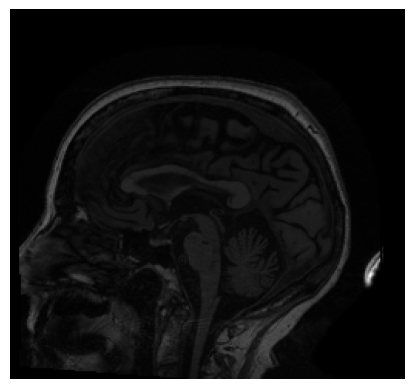

In [87]:
plt.imshow(data[:, :, data.shape[2] // 2], cmap="gray")
plt.axis("off")
plt.show()

In [88]:
def get_counts(df: pd.DataFrame, feature: str, split_value: float = -1.0) -> pd.DataFrame:
    
    if split_value != -1:
        below_or_equal = df[df[feature] <= split_value].shape[0]
        above = df[df[feature] > split_value].shape[0]
        total = below_or_equal + above
        summary = pd.DataFrame({
            'Count': [below_or_equal, above],
            'Percentage': [round(below_or_equal / total * 100, 3), round(above / total * 100, 3)]
        }, index=[f'≤ {split_value}', f'> {split_value}'])
        return summary
    
    counts = df[feature].value_counts()
    percentages = df[feature].value_counts(normalize=True) * 100

    summary = pd.DataFrame({
        'Count': counts,
        'Percentage': percentages.round(3)
    })
    return summary

In [89]:
def plot_histogram_comparison(train: pd.Series, val: pd.Series, test: pd.Series, feature: str,bins: int = 50) -> None:
    plt.figure(figsize=(10, 6))

    # Plot histograms on the same axis
    plt.hist(train.dropna(), bins=bins//3,label='Train', color='blue', edgecolor='black', weights=np.ones(len(train)) * 100 / len(train))
    plt.hist(val.dropna(),   bins=bins//3,label='Val',   color='red', edgecolor='black', weights=np.ones(len(val)) * 100 / len(val))
    plt.hist(test.dropna(),  bins=bins, label='Test',  color='green', edgecolor='black', weights=np.ones(len(test)) * 100 / len(test))

    # Customize
    plt.title(f'{feature} Distribution', fontsize=18)
    plt.xlabel(feature, fontsize=16)
    plt.ylabel('% of split', fontsize=16)
    plt.legend(fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.tight_layout()
    plt.show()

In [90]:
def plot_distributions(df: pd.DataFrame, feature: str, highlight_dict: dict[int, str] = {}, misc_limit: int = 0, bins: int = 50) -> None:
    counts_df = get_counts(df=df, feature=feature)
    
    plt.figure(figsize=(10, 6))

    if len(counts_df) > 50:
        counts_df.sort_index(inplace=True)
        counts, bins_edges = np.histogram(counts_df.index, bins=bins)

        # Convert counts to percentage
        percentages = counts / counts.sum() * 100

        # Compute bin centers for correct alignment
        bin_centers = (bins_edges[:-1] + bins_edges[1:]) / 2
        bar_widths = np.diff(bins_edges)

        # Plot the histogram manually using bar
        plt.bar(bin_centers, percentages, width=bar_widths, align='center',
                alpha=0.5, label='Train', color='blue', edgecolor='black')
        plt.ylabel('Percentage %')

    else:
        # Step 1: Summarize entries below threshold
        low_count = counts_df[counts_df["Count"] < misc_limit]
        high_count = counts_df[counts_df["Count"] >= misc_limit]

        # Step 2: Add "Miscellaneous" as a new row
        misc_total = low_count["Count"].sum()
        misc_perc = low_count["Percentage"].sum()
        if misc_total > 0:
            misc_row = pd.DataFrame({"Count": [misc_total], "Percentage": [misc_perc]}, index=["Miscellaneous"])
            df_plot = pd.concat([high_count, misc_row])
        else:
            df_plot = high_count.copy()

        ## Step 3: Sort (optional)
        #df_plot = df_plot.sort_values(by="Count", ascending=False)

        # Step 4: Plot
        ax = df_plot["Count"].plot(kind='bar', color='skyblue', edgecolor='black', width=1)
        plt.ylabel('Frequency', fontsize=16)

        # Step 5: Highlight selected bars using the new index
        for i, label in enumerate(df_plot.index):
            if i in highlight_dict:
                ax.patches[i].set_facecolor(highlight_dict[i])
                
            if len(plt.gca().get_xticks()) > 50:
                plt.locator_params(axis='x', nbins=25)

    # Customize the plot
    plt.title(f'{feature} distribution', fontsize=18)
    plt.xlabel(feature, fontsize=16)
    plt.tight_layout()
    plt.xticks(rotation=45, fontsize=14)
    plt.yticks(fontsize=14)

    # Show the plot
    plt.show()

In [91]:
def calc_normalized_dists(count_df: pd.DataFrame) -> pd.DataFrame:
    return count_df['Count'] / count_df['Count'].sum()

In [92]:
def plot_compare_distribution(train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame, feature: str, feature_name: str) -> None:
    train_counts = get_counts(df=train_df, feature=feature)
    val_counts = get_counts(df=val_df, feature=feature)
    test_counts = get_counts(df=test_df, feature=feature)

    train_norm = calc_normalized_dists(count_df=train_counts)
    val_norm = calc_normalized_dists(count_df=val_counts)
    test_norm = calc_normalized_dists(count_df=test_counts)   
    
    train_pct = train_norm / train_norm.sum() * 100
    val_pct = val_norm / val_norm.sum() * 100
    test_pct = test_norm / test_norm.sum() * 100
    
    display(train_pct)
    display(val_pct)
    display(test_pct)
    
    plt.figure(figsize=(12, 6))
    plt.plot(feature, train_pct, label='Train', marker='o')
    plt.plot(feature, val_pct, label='Validation', marker='s')
    plt.plot(feature, test_pct, label='Test', marker='^')
    plt.xticks(rotation=45)
    
    plt.ylabel('% of split')
    plt.title(f'{feature_name} Distribution Comparison')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [93]:
def denormalize_column(df: pd.DataFrame, column: str, means: pd.Series, stds: pd.Series) -> pd.Series:
    mean = means[column]
    std = stds[column]
    col = df[column] * std + mean
    return col.reset_index(drop=True)

In [94]:
def plot_histogram_comparison(train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame, feature: str, bins: int = 50) -> None:
    plt.figure(figsize=(10, 6))

    # Plot histograms on the same axis
    plt.hist(train_df[feature].dropna(), bins=bins, label='Train', color='blue', edgecolor='black', weights=np.ones(len(train_df)) * 100 / len(train_df))
    plt.hist(val_df[feature].dropna(),   bins=bins, label='Val',   color='red', edgecolor='black', weights=np.ones(len(val_df)) * 100 / len(val_df))
    plt.hist(test_df[feature].dropna(),  bins=bins, label='Test',  color='green', edgecolor='black', weights=np.ones(len(test_df)) * 100 / len(test_df))

    # Customize
    plt.title(f'{feature} Distribution', fontsize=18)
    plt.xlabel(feature, fontsize=16)
    plt.ylabel('% of split', fontsize=16)
    plt.legend(fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.tight_layout()
    plt.show()

## Load Data

In [95]:
def get_leaf_directories(root_dir):
    leaf_dirs = []
    root_dir = root_dir if isinstance(root_dir, list) else [root_dir]
    for root in root_dir:
        for dirpath, dirnames, filenames in os.walk(root):
            if not dirnames:  # no subdirectories → it's a leaf
                leaf_dirs.append(dirpath)
    return leaf_dirs

def get_files(dir):
    return [os.path.join(dir, f) for f in os.listdir(dir) if os.path.isfile(os.path.join(dir, f))]

In [96]:
def get_subject_dicts(collections: list[str], base_path: str):
    subject_dict_list = []
    for c in collections:
        TAB_PATH = os.path.join(base_path, f"{c}/{c}_metadata")
        IM_PATH = os.path.join(base_path, f"{c}/{c}/ADNI")

        subjects = [i for i in os.listdir(TAB_PATH) if os.path.isdir(os.path.join(TAB_PATH, i))]
        print(len(subjects))

        subject_metadata_dir = {k: [] for k in subjects}
        for key in subject_metadata_dir.keys():
            for i in os.listdir(TAB_PATH):
                path = os.path.join(TAB_PATH, i)
                if not os.path.isfile(path):
                    continue
                if key in path:
                    subject_metadata_dir[key].append(path)

        subject_image_dir = {k: "" for k in subjects}
        for key in subject_image_dir.keys():
            for i in os.listdir(IM_PATH):
                path = os.path.join(IM_PATH, i)
                if not os.path.isdir(path):
                    continue
                if key in path:
                    subject_image_dir[key] = path

        subject_image_ids_dir = {k: get_leaf_directories(v) for k, v in subject_image_dir.items()}
        subject_image_ids = {k: [os.path.basename(path) for path in v] for k, v in subject_image_ids_dir.items()}

        for sub in subjects:
            new_dict: dict[str, Any] = {"subject_id": sub}
            new_dict["data"] = []
            for ids in subject_image_ids[sub]:
                id_metapath = [s for s in subject_metadata_dir[sub] if ids in s][0]
                id_image = [im for im in get_leaf_directories(subject_image_ids_dir[sub]) if ids in im][0]
                id_image = get_files(id_image)[0]
                new_dict["data"].append({"tab_path": id_metapath, "image_path": id_image, "id": ids})
            subject_dict_list.append(new_dict)

    return subject_dict_list

In [97]:
import re
import xml.etree.ElementTree as ET
import pandas as pd

def parse_ida_xml_to_dataframe(xml_path: str) -> pd.DataFrame:
    """
    Parse an IDA XML file (like ADNI structure) into a flat pandas DataFrame.
    - Handles mixed namespaces automatically.
    - Produces one row per subject/visit/study/series combination.
    - Assessment scores, subjectInfo entries, and image protocol terms become columns.
    """

    # --- Load XML and strip namespaces ---
    with open(xml_path, "r", encoding="utf-8") as f:
        xml_text = f.read()

    xml_text = re.sub(r'\sxmlns(:\w+)?="[^"]+"', '', xml_text)
    xml_text = re.sub(r'xsi:[a-zA-Z]+="[^"]+"', '', xml_text)

    root = ET.fromstring(xml_text)

    records = []

    for project in root.findall(".//project"):
        project_id = project.findtext("projectIdentifier")
        project_desc = project.findtext("projectDescription")
        site_key = project.findtext("siteKey")

        for subject in project.findall(".//subject"):
            subj_id = subject.findtext("subjectIdentifier")
            group = subject.findtext("researchGroup")
            sex = subject.findtext("subjectSex")

            # --- Gather <subjectInfo> key-value pairs ---
            subject_info = {}
            for info in subject.findall(".//subjectInfo"):
                key = info.get("item")
                val = info.text
                if key:
                    subject_info[key] = val

            # --- Study info ---
            for study in subject.findall(".//study"):
                study_id = study.findtext("studyIdentifier")
                subj_age = study.findtext("subjectAge")
                weight = study.findtext("weightKg")
                postmortem = study.findtext("postMortem")

                for series in study.findall(".//series"):
                    series_id = series.findtext("seriesIdentifier")
                    modality = series.findtext("modality")
                    date_acq = series.findtext("dateAcquired")

                    # --- Extract protocol-level metadata (slice thickness, TE, TR, etc.) ---
                    protocol_info = {}
                    for proto in series.findall(".//protocol"):
                        term = proto.get("term")
                        val = proto.text
                        if term:
                            protocol_info[term] = val

                    base_record = {
                        "projectIdentifier": project_id,
                        "projectDescription": project_desc,
                        "siteKey": site_key,
                        "subjectIdentifier": subj_id,
                        "researchGroup": group,
                        "subjectSex": sex,
                        "studyIdentifier": study_id,
                        "subjectAge": subj_age,
                        "weightKg": weight,
                        "postMortem": postmortem,
                        "seriesIdentifier": series_id,
                        "modality": modality,
                        "dateAcquired": date_acq,
                    }

                    # Add subjectInfo and protocol details
                    base_record.update(subject_info)
                    base_record.update(protocol_info)

                    # --- Visits and Assessments ---
                    for visit in subject.findall(".//visit"):
                        visit_id = visit.findtext("visitIdentifier")
                        record = base_record.copy()
                        record["visitIdentifier"] = visit_id

                        # Collect assessments into columns
                        for assessment in visit.findall(".//assessment"):
                            for component in assessment.findall(".//component"):
                                score_elem = component.find(".//assessmentScore")
                                if score_elem is not None:
                                    score_attr = score_elem.get("attribute")
                                    score_value = score_elem.text
                                    if score_attr:
                                        record[score_attr] = score_value

                        records.append(record)

    df = pd.DataFrame(records)
    df = df.drop_duplicates()

    return df

In [98]:
collections = ["ADNI1_Annual_2_Yr_3T", "ADNI1_Complete_1Yr_3T", "ADNI1_Complete_1Yr_1.5T", "ADNI1_Complete_2Yr_1.5T", "ADNI1_Complete_2Yr_3T", "ADNI1_Complete_3Yr_1.5T", "ADNI1_Complete_3Yr_3T"]

subject_dict_list = get_subject_dicts(collections=collections, base_path=BASE_PATH)
len(subject_dict_list)

89
119
639
419
36
382
42


1726

In [99]:
def get_tabular_data(dict_list):
    df_full = pd.DataFrame()
    for d in dict_list:
        for point in d["data"]:
            path = point["tab_path"]
            df = parse_ida_xml_to_dataframe(path)
            df["im_path"] = point["image_path"]
            df["dataIdentifier"] = df["subjectIdentifier"] + "_" + df["studyIdentifier"]
            if df_full.empty:
                df_full = df
            else:
                df_full = pd.concat([df_full, df])
    return df_full.reset_index(drop=True)
                
tab_data = get_tabular_data(dict_list=subject_dict_list)
tab_data

,projectIdentifier,projectDescription,siteKey,subjectIdentifier,researchGroup,subjectSex,studyIdentifier,subjectAge,weightKg,postMortem,...,Mfg Model,Field Strength,visitIdentifier,NPISCORE,FAQTOTAL,im_path,dataIdentifier,MMSCORE,GDTOTAL,CDGLOBAL
0,ADNI,Alzheimer's Disease Neuroimaging Initiative,130,130_S_0449,MCI,F,4893,66.8466,58.06,F,...,Achieva,3.0,ADNI Baseline,0.0,0.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,130_S_0449_4893,NaN,NaN,NaN
1,ADNI,Alzheimer's Disease Neuroimaging Initiative,130,130_S_0449,MCI,F,11625,67.8767,56.7,F,...,Achieva,3.0,ADNI1/GO Month 12,1.0,0.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,130_S_0449_11625,27.0,2.0,0.5
2,ADNI,Alzheimer's Disease Neuroimaging Initiative,130,130_S_0449,MCI,F,17355,68.8356,60.78,F,...,Achieva,3.0,ADNI1/GO Month 24,3.0,11.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,130_S_0449_17355,29.0,1.0,0.5
3,ADNI,Alzheimer's Disease Neuroimaging Initiative,116,116_S_0382,CN,F,4239,75.6986,63.73,F,...,Trio,2.89362,ADNI Baseline,0.0,0.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,116_S_0382_4239,NaN,NaN,NaN
4,ADNI,Alzheimer's Disease Neuroimaging Initiative,116,116_S_0382,CN,F,9326,76.6986,63.5,F,...,Trio,3.0,ADNI1/GO Month 12,0.0,0.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,116_S_0382_9326,29.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4598,ADNI,Alzheimer's Disease Neuroimaging Initiative,032,032_S_1169,CN,F,24831,75.3315,74.84,F,...,TrioTim,3.0,ADNI1/GO Month 36,0.0,0.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,032_S_1169_24831,30.0,3.0,0.5
4599,ADNI,Alzheimer's Disease Neuroimaging Initiative,023,023_S_0331,MCI,F,20973,67.7151,61.6,F,...,Trio,3.0,ADNI1/GO Month 36,3.0,5.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,023_S_0331_20973,23.0,8.0,0.5
4600,ADNI,Alzheimer's Disease Neuroimaging Initiative,023,023_S_0331,MCI,F,13134,66.211,64.41,F,...,Trio,3.0,ADNI1/GO Month 18,3.0,3.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,023_S_0331_13134,25.0,NaN,0.5
4601,ADNI,Alzheimer's Disease Neuroimaging Initiative,136,136_S_0429,MCI,M,22163,65.8849,79.38,F,...,Achieva,3.0,ADNI1/GO Month 36,5.0,4.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,136_S_0429_22163,26.0,4.0,0.5


In [100]:
tab_data.columns

Index(['projectIdentifier', 'projectDescription', 'siteKey',
       'subjectIdentifier', 'researchGroup', 'subjectSex', 'studyIdentifier',
       'subjectAge', 'weightKg', 'postMortem', 'seriesIdentifier', 'modality',
       'dateAcquired', 'APOE A1', 'APOE A2', 'Acquisition Type', 'Weighting',
       'Pulse Sequence', 'Slice Thickness', 'TE', 'TR', 'TI', 'Coil',
       'Flip Angle', 'Acquisition Plane', 'Matrix X', 'Matrix Y', 'Matrix Z',
       'Pixel Spacing X', 'Pixel Spacing Y', 'Manufacturer', 'Mfg Model',
       'Field Strength', 'visitIdentifier', 'NPISCORE', 'FAQTOTAL', 'im_path',
       'dataIdentifier', 'MMSCORE', 'GDTOTAL', 'CDGLOBAL'],
      dtype='object')

In [101]:
(tab_data.isna().sum() / len(tab_data) * 100).sort_values(ascending=False)

GDTOTAL               35.411688
FAQTOTAL              18.770367
NPISCORE              18.487943
Acquisition Type      14.142950
MMSCORE                6.495764
CDGLOBAL               6.408864
siteKey                0.000000
projectDescription     0.000000
projectIdentifier      0.000000
weightKg               0.000000
subjectAge             0.000000
studyIdentifier        0.000000
subjectSex             0.000000
researchGroup          0.000000
subjectIdentifier      0.000000
modality               0.000000
postMortem             0.000000
Pulse Sequence         0.000000
Slice Thickness        0.000000
TE                     0.000000
seriesIdentifier       0.000000
dateAcquired           0.000000
APOE A1                0.000000
APOE A2                0.000000
Weighting              0.000000
Acquisition Plane      0.000000
Flip Angle             0.000000
Coil                   0.000000
TI                     0.000000
TR                     0.000000
Matrix X               0.000000
Matrix Z

In [102]:
tab_data["dataIdentifier"].nunique()

3412

In [103]:
relevant_cols = ["dataIdentifier", "subjectIdentifier", "researchGroup", "subjectSex", "subjectAge", "weightKg", "NPISCORE", "FAQTOTAL", "im_path", "MMSCORE", "CDGLOBAL", "APOE A1", "APOE A2", "Slice Thickness", "Field Strength", "TE", "TR", "TI", "Manufacturer"]

df_no_nan = tab_data.dropna(subset=relevant_cols)

relevant_df = df_no_nan[relevant_cols].reset_index(drop=True)
relevant_df = relevant_df.drop_duplicates(subset='dataIdentifier', keep='first').reset_index(drop=True)

# possible labels
# CN: cognitively normal
# MCI: mild cognitive impairment
# AD: Alzheimer's disease
#relevant_df["researchGroup"].unique()
print(relevant_df.shape)

(2620, 19)


In [104]:
def fix_dtypes(df: pd.DataFrame, dtypes: dict[str, str]) -> pd.DataFrame:
    for col, dtype in dtypes.items():
        if col not in df.columns:
            print(f"Warning: Column '{col}' not found in DataFrame, skipping.")
            continue
        
        try:
            # Special case for datetime
            if "datetime" in dtype:
                df[col] = pd.to_datetime(df[col], errors="coerce")
            else:
                df[col] = df[col].astype(dtype)
        except Exception as e:
            print(f"Could not convert column '{col}' to {dtype}: {e}")
    
    return df

In [105]:
relevant_df

,dataIdentifier,subjectIdentifier,researchGroup,subjectSex,subjectAge,weightKg,NPISCORE,FAQTOTAL,im_path,MMSCORE,CDGLOBAL,APOE A1,APOE A2,Slice Thickness,Field Strength,TE,TR,TI,Manufacturer
0,130_S_0449_11625,130_S_0449,MCI,F,67.8767,56.7,1.0,0.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,27.0,0.5,4,4,1.2,3.0,3.2544,6.8482,0.0,Philips Medical Systems
1,130_S_0449_17355,130_S_0449,MCI,F,68.8356,60.78,3.0,11.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,29.0,0.5,4,4,1.2,3.0,3.2544,6.8482,0.0,Philips Medical Systems
2,116_S_0382_9326,116_S_0382,CN,F,76.6986,63.5,0.0,0.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,29.0,0.0,3,3,1.2,3.0,2.94,2300.0,900.0,SIEMENS
3,116_S_0382_16134,116_S_0382,CN,F,77.6575,63.5,2.0,0.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,29.0,0.0,3,3,1.2,3.0,2.94,2300.0,900.0,SIEMENS
4,023_S_1190_19390,023_S_1190,CN,F,78.6658,60.51,1.0,0.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,30.0,0.0,3,3,1.2,3.0,2.94,2300.0,900.0,SIEMENS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2615,023_S_0926_23726,023_S_0926,CN,F,74.2986,75.21,0.0,0.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,30.0,0.0,3,3,1.2,3.0,2.94,2300.0,900.0,SIEMENS
2616,018_S_0450_22011,018_S_0450,MCI,M,71.7014,52.16,2.0,9.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,26.0,1.0,3,4,1.2,3.0,3.1329,6.7657,0.0,Philips Medical Systems
2617,032_S_1169_24831,032_S_1169,CN,F,75.3315,74.84,0.0,0.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,30.0,0.5,3,3,1.2,3.0,2.91,2300.0,900.0,SIEMENS
2618,023_S_0331_20973,023_S_0331,MCI,F,67.7151,61.6,3.0,5.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,23.0,0.5,4,4,1.2,3.0,2.94,2300.0,900.0,SIEMENS


In [106]:
relevant_df["Manufacturer"].value_counts()

GE MEDICAL SYSTEMS         1217
SIEMENS                    1041
Philips Medical Systems     362
Name: Manufacturer, dtype: int64

In [107]:
correct_dtypes = {"dataIdentifier": "string", "subjectIdentifier": "string", "researchGroup": "string", "subjectSex": "string",
                  "subjectAge": "float64", "weightKg": "float64", "NPISCORE": "float64", "FAQTOTAL": "float64", "im_path": "string",
                  "MMSCORE": "float64", "CDGLOBAL": "float64", "APOE A1": "int64", "APOE A2": "int64",
                  "Slice Thickness": "float64", "Field Strength": "float64", "TE": "float64", "TR": "float64", "TI": "float64", "Manufacturer": "string"}
relevant_df = fix_dtypes(df=relevant_df, dtypes=correct_dtypes)

In [108]:
relevant_df.dtypes

dataIdentifier        string
subjectIdentifier     string
researchGroup         string
subjectSex            string
subjectAge           float64
weightKg             float64
NPISCORE             float64
FAQTOTAL             float64
im_path               string
MMSCORE              float64
CDGLOBAL             float64
APOE A1                int64
APOE A2                int64
Slice Thickness      float64
Field Strength       float64
TE                   float64
TR                   float64
TI                   float64
Manufacturer          string
dtype: object

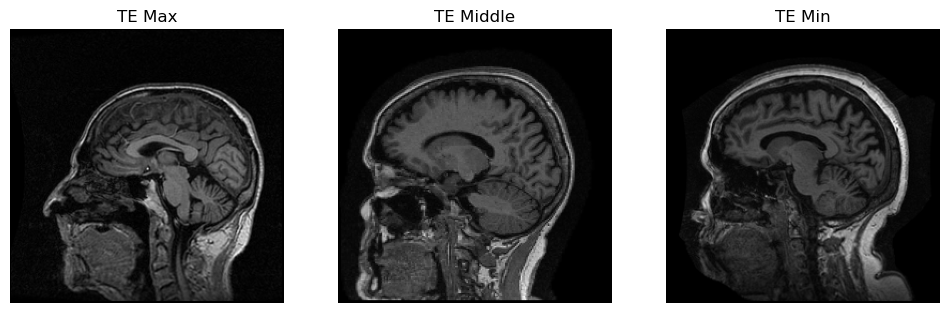

In [109]:
img_col = "TE"

img_te_max = nib.load(relevant_df.loc[relevant_df[img_col].idxmax()]["im_path"])
img_te_min = nib.load(relevant_df.loc[relevant_df[img_col].idxmin()]["im_path"])
middle_row = relevant_df.loc[(relevant_df[img_col] - (relevant_df[img_col].max() + relevant_df[img_col].min()) / 2).abs().idxmin()]["im_path"]
img_te_middle = nib.load(middle_row)

data_te_max = img_te_max.get_fdata()
data_te_min = img_te_min.get_fdata()
data_te_middle = img_te_middle.get_fdata()

slice_index = data_te_max.shape[2] // 2
slice_max = data_te_max[:, :, slice_index]
slice_min = data_te_min[:, :, slice_index]
slice_middle = data_te_middle[:, :, slice_index]

# Create side-by-side plots
fig, axes = plt.subplots(1, 3, figsize=(12, 6))  # 1 row, 2 columns

# Left image
axes[0].imshow(slice_max, cmap="gray")
axes[0].axis("off")
axes[0].set_title(f"{img_col} Max")

# Middle image
axes[1].imshow(slice_middle, cmap="gray")
axes[1].axis("off")
axes[1].set_title(f"{img_col} Middle")

# Right image
axes[2].imshow(slice_min, cmap="gray")
axes[2].axis("off")
axes[2].set_title(f"{img_col} Min")

plt.show()

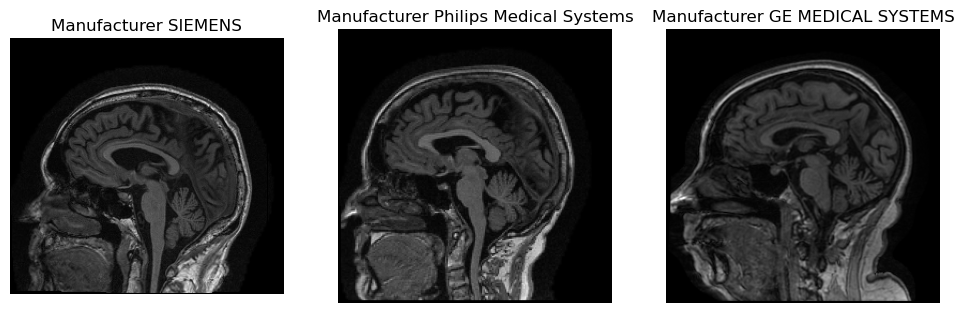

In [110]:
img_col = "Manufacturer"

img_te_max = nib.load(relevant_df[relevant_df[img_col] == "SIEMENS"]["im_path"].reset_index(drop=True)[50])
img_te_min = nib.load(relevant_df[relevant_df[img_col] == "GE MEDICAL SYSTEMS"]["im_path"].reset_index(drop=True)[50])
img_te_middle = nib.load(relevant_df[relevant_df[img_col] == "Philips Medical Systems"]["im_path"].reset_index(drop=True)[50])

data_te_max = img_te_max.get_fdata()
data_te_min = img_te_min.get_fdata()

slice_index = data_te_max.shape[2] // 2
slice_max = data_te_max[:, :, slice_index]
slice_min = data_te_min[:, :, slice_index]
slice_middle = data_te_middle[:, :, slice_index]

# Create side-by-side plots
fig, axes = plt.subplots(1, 3, figsize=(12, 6))  # 1 row, 2 columns

# Left image
axes[0].imshow(slice_max, cmap="gray")
axes[0].axis("off")
axes[0].set_title(f"{img_col} SIEMENS")

# Middle image
axes[1].imshow(slice_middle, cmap="gray")
axes[1].axis("off")
axes[1].set_title(f"{img_col} Philips Medical Systems")

# Right image
axes[2].imshow(slice_min, cmap="gray")
axes[2].axis("off")
axes[2].set_title(f"{img_col} GE MEDICAL SYSTEMS")

plt.show()

In [111]:
def get_slice(path):
    img = nib.load(path)
    data = img.get_fdata()
    slice = data[:, :, data.shape[2] // 2]
    slice_norm = (slice - np.min(slice)) / (np.max(slice) - np.min(slice))
    slice_uint8 = (slice_norm * 255).astype(np.uint8)
    return slice_uint8

def get_png_path(path: str, dir: str):
    return os.path.join(dir, os.path.basename(path)[:-3] + "png")
    
def save_image(series: pd.Series, dir: str):
    for row in series:
        png_path = get_png_path(path=row, dir=dir)
        if not os.path.exists(png_path):
            img = get_slice(path=row)
            # Save as PNG
            imageio.imwrite(png_path, img)

save_image(series=relevant_df["im_path"], dir=PROCESSED_PATH)

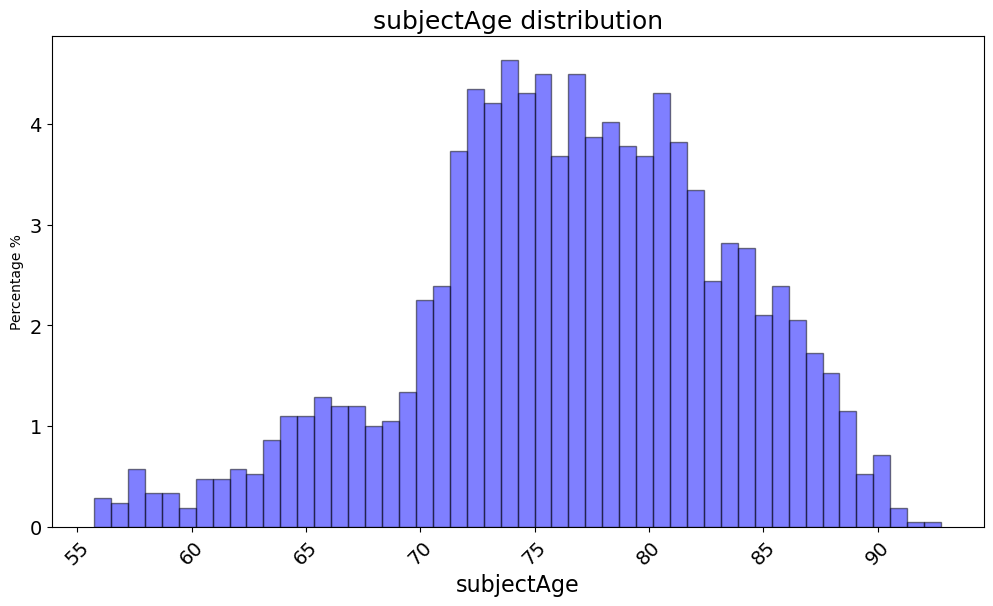

In [112]:
plot_distributions(df=relevant_df, feature="subjectAge")

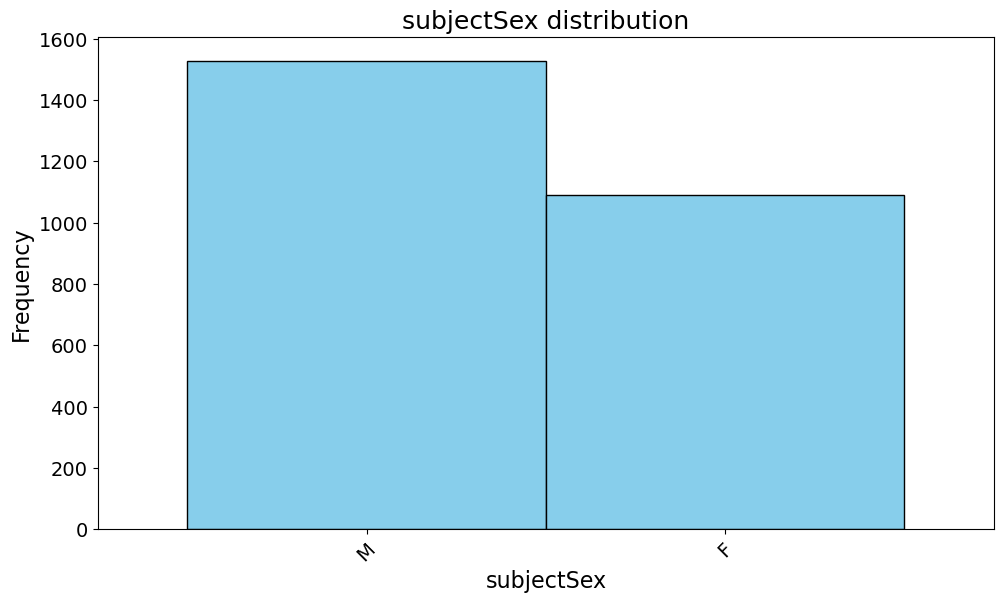

In [113]:
plot_distributions(df=relevant_df, feature="subjectSex")

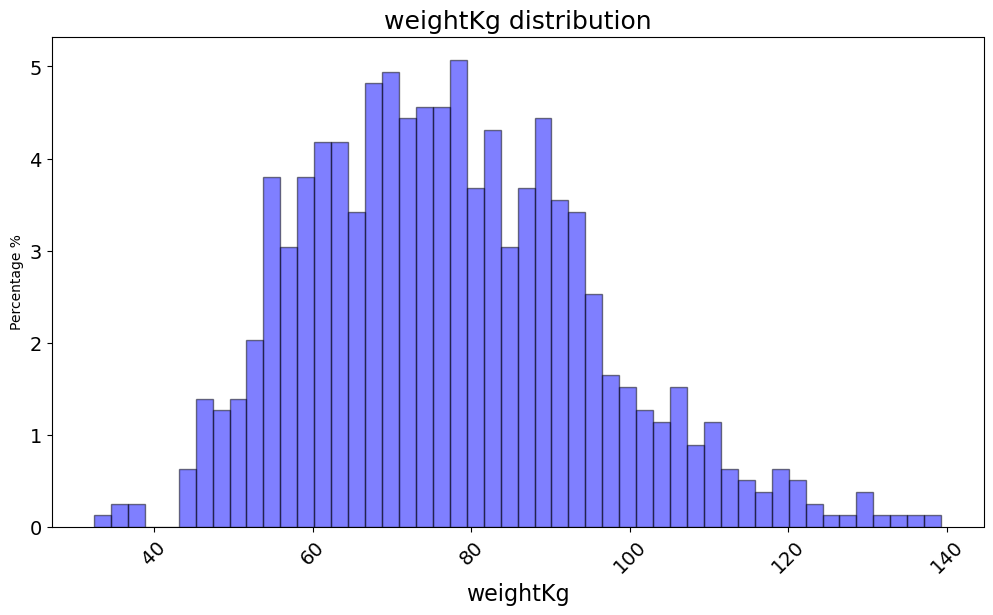

In [114]:
relevant_df = relevant_df[relevant_df["weightKg"] > 0.0]
plot_distributions(df=relevant_df, feature="weightKg")

In [115]:
relevant_df.shape

(2618, 19)

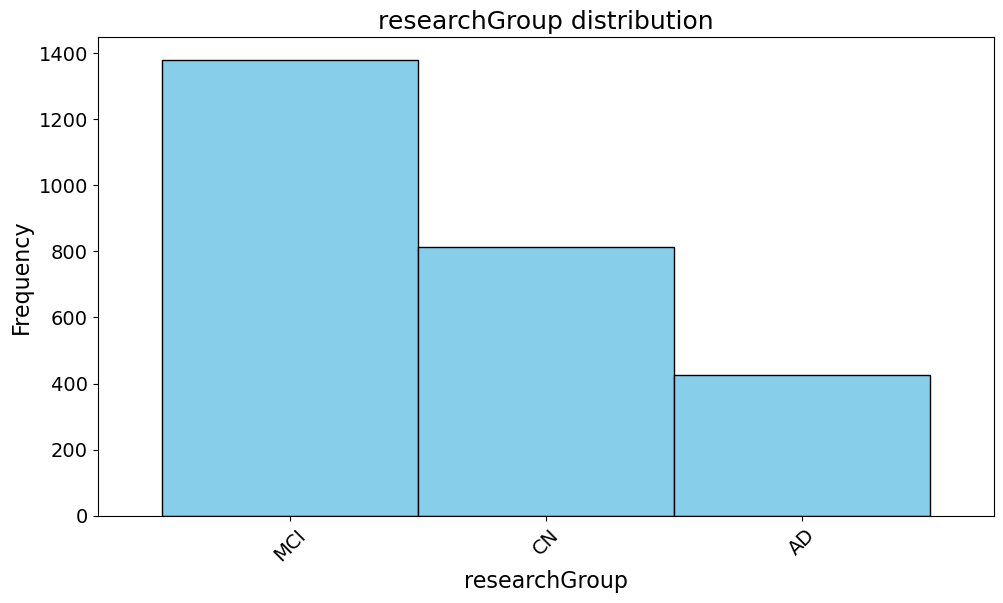

In [116]:
plot_distributions(df=relevant_df, feature="researchGroup")

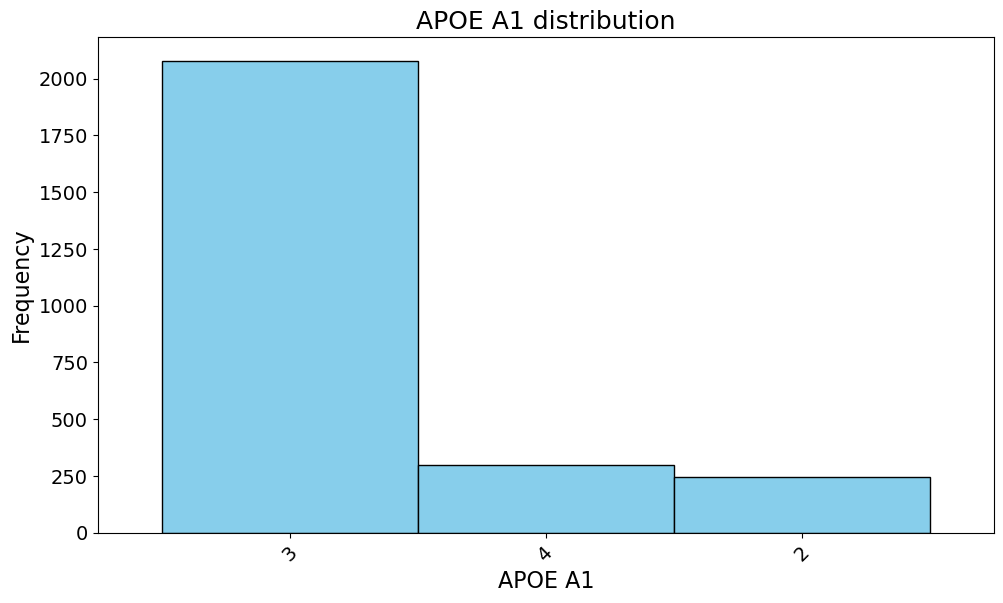

In [117]:
plot_distributions(df=relevant_df, feature="APOE A1")

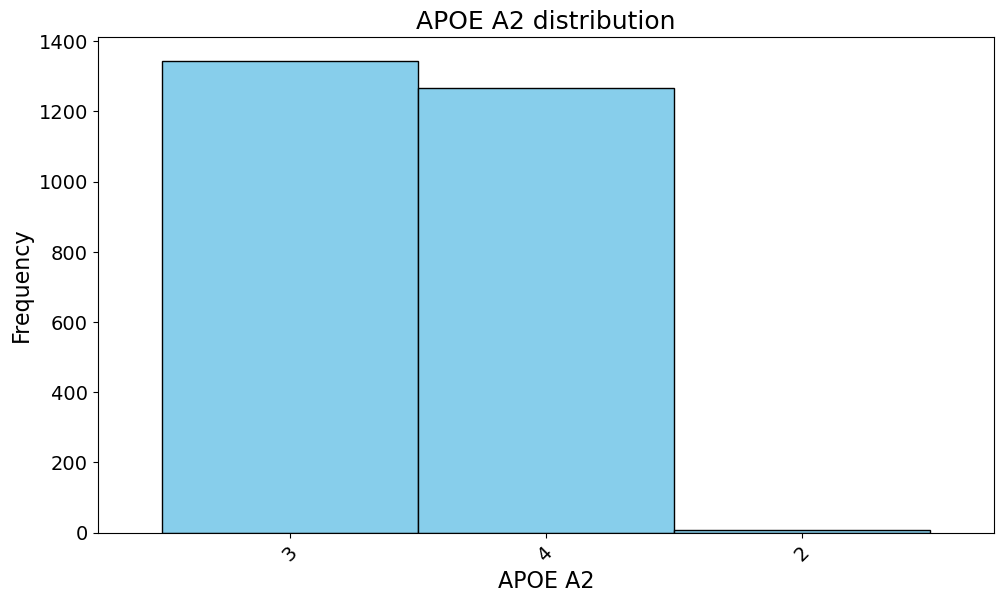

In [118]:
plot_distributions(df=relevant_df, feature="APOE A2")

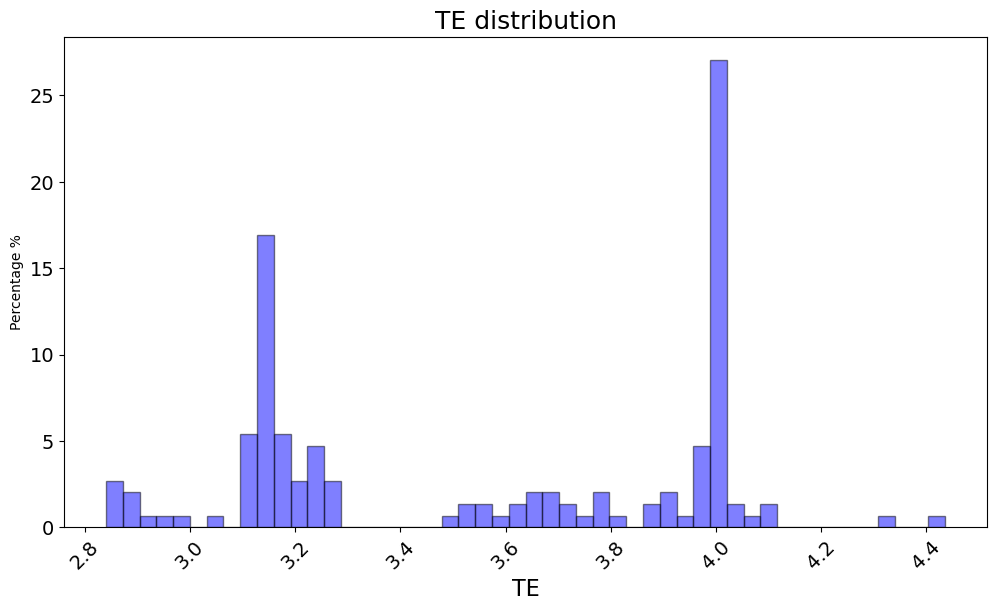

In [119]:
plot_distributions(df=relevant_df, feature="TE")

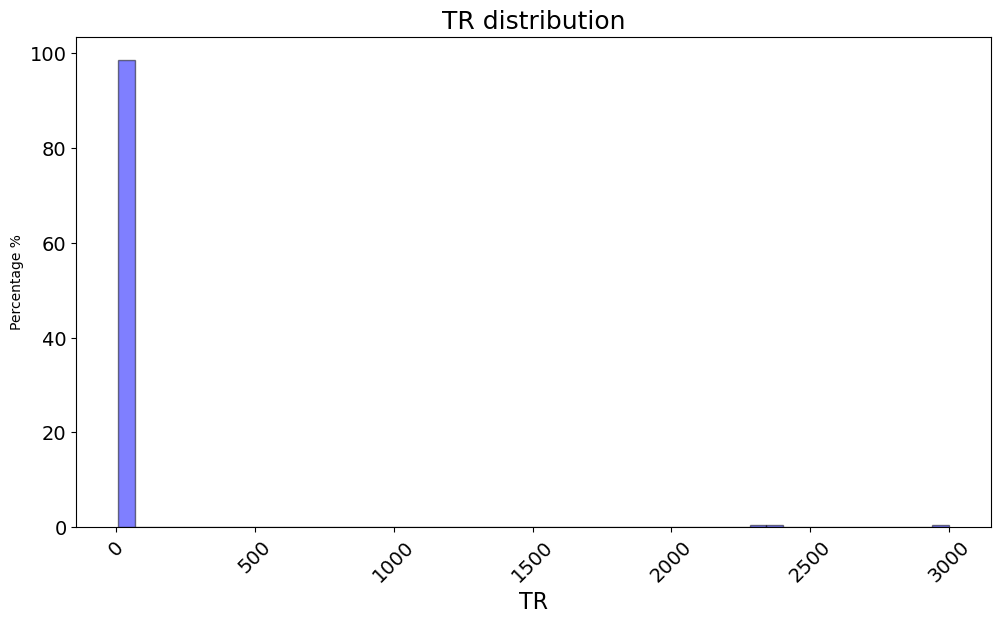

In [120]:
plot_distributions(df=relevant_df, feature="TR")

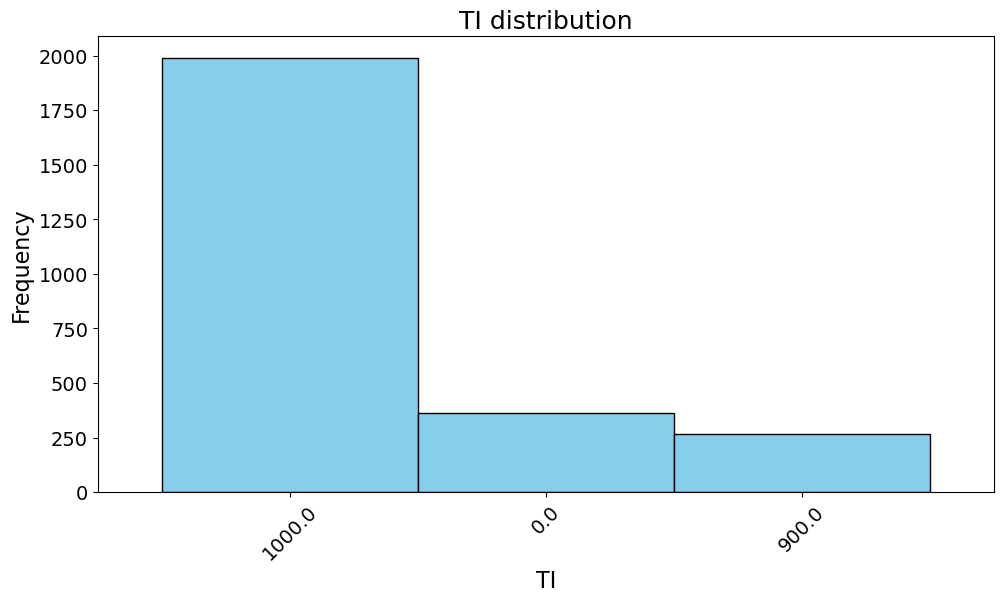

In [121]:
plot_distributions(df=relevant_df, feature="TI")

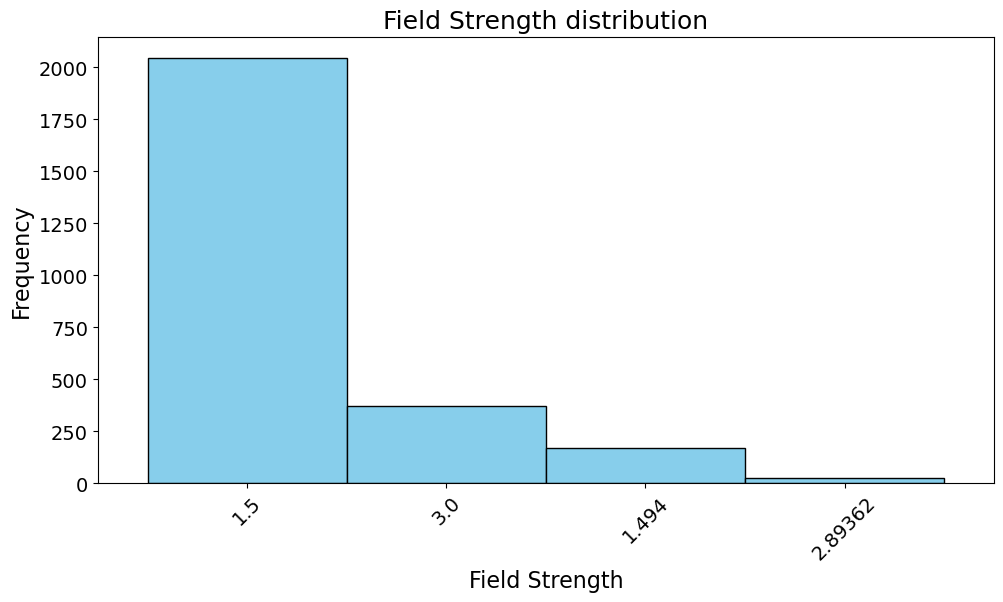

In [122]:
plot_distributions(df=relevant_df, feature="Field Strength")

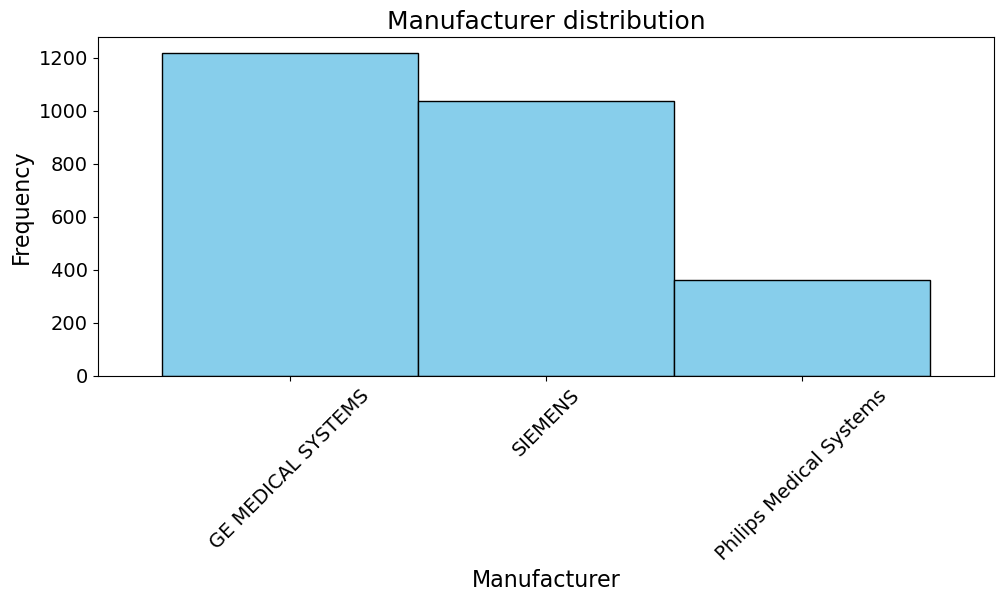

In [123]:
plot_distributions(df=relevant_df, feature="Manufacturer")

## Split Data

In [124]:
def create_shift_mask(df: pd.DataFrame, filters: list[Dict[str, str]], filter_cond: str, con_columns: list[str], cat_columns: list[str]) -> pd.Series:
    first_bool = True if filter_cond == "and" else False
    
    ops = {
        "==": operator.eq,
        "!=": operator.ne,
        ">": operator.gt,
        ">=": operator.ge,
        "<": operator.lt,
        "<=": operator.le,
    }

    mask = pd.Series(first_bool, index=df.index)
    for f in filters:
        for col, val in f.items():
            if col in con_columns:
                if isinstance(val, tuple):
                    op_str, threshold = val
                    mask &= ops[op_str](df[col], threshold)
                else:
                    mask &= df[col] == val
            elif col in cat_columns:
                if isinstance(val, tuple):
                    op_str, threshold = val
                    mask |= ops[op_str](df[col], threshold)
                else:
                    mask |= df[col] == val
                    
    return mask

In [125]:
def data_split(df: pd.DataFrame, nclasses: int, split: Union[float, int]) -> np.ndarray:
    # 1. Keep only top-n classes
    top_classes = df['researchGroup'].value_counts().nlargest(nclasses).index
    df = df[df['researchGroup'].isin(top_classes)].copy()

    # 2. Aggregate by subject: one row per subject
    # Each subject gets a single representative label (mode of researchGroup)
    subject_labels = (
        df.groupby('subjectIdentifier')['researchGroup']
        .agg(lambda x: x.mode()[0])
        .reset_index()
    )

    # 3. Convert split to test_size (since StratifiedShuffleSplit expects test_size)
    if isinstance(split, int):
        train_size = split / len(df)
    else:
        train_size = split
    test_size = 1 - train_size

    # 4. Perform stratified split at subject level
    sss = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=2023)
    train_idx, test_idx = next(sss.split(subject_labels, subject_labels['researchGroup']))

    train_subjects = subject_labels.iloc[train_idx]['subjectIdentifier']
    test_subjects = subject_labels.iloc[test_idx]['subjectIdentifier']

    # 5. Map back to full dataset
    train_df = df[df['subjectIdentifier'].isin(train_subjects)]
    test_df = df[df['subjectIdentifier'].isin(test_subjects)]

    # 6. Sanity checks
    assert not set(train_df['subjectIdentifier']) & set(test_df['subjectIdentifier']), \
        "Overlap detected: a subject appears in both splits!"

    return train_df["dataIdentifier"].values

In [126]:
def create_cutted_split(df: pd.DataFrame, size: float) -> tuple[pd.DataFrame, pd.DataFrame]:
    nclasses = df["researchGroup"].nunique()
    df_ids = data_split(df=df, nclasses=nclasses, split=size)
    first_df = df.loc[df['dataIdentifier'].isin(df_ids)]
    second_df = df.loc[~df['dataIdentifier'].isin(df_ids)]
    return first_df.reset_index(drop=True), second_df.reset_index(drop=True)

In [127]:
def create_dataset(tab_data: pd.DataFrame, train_ratio: float, val_ratio: float, test_ratio: float):
    train_val, test = create_cutted_split(df=tab_data, size=1 - test_ratio)
    val_size_relative = val_ratio / (train_ratio + val_ratio)
    train, val = create_cutted_split(df=train_val, size=1 - val_size_relative)
    return train, val, test

In [128]:
def categorize(train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame, categorical_columns: list[str]) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, Dict[str, dict]]:
    # Deep copies to ensure no slice/view issues
    train_df_copy = train_df.copy(deep=True)
    val_df_copy = val_df.copy(deep=True)
    test_df_copy = test_df.copy(deep=True)
    
    category_mappings = {}

    for col in categorical_columns:
        # Combine all categories
        all_categories = pd.Index(
            pd.concat([
                train_df_copy[col],
                val_df_copy[col],
                test_df_copy[col]
            ]).dropna().unique()
        )
        
        # Store the mapping
        mapping = {category: code for code, category in enumerate(all_categories)}
        category_mappings[col] = mapping

        # Assign categories
        for df in (train_df_copy, val_df_copy, test_df_copy):
            df[col] = pd.Categorical(df[col], categories=all_categories)
            df[col] = df[col].cat.codes

    return train_df_copy, val_df_copy, test_df_copy, category_mappings

In [129]:
def normalize(train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame, continuous_columns: list[str]) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    # Compute mean and std from training set only
    mean = train_df[continuous_columns].mean()
    std = train_df[continuous_columns].std()
    
    non_constant_columns = std[std != 0].index.tolist()

    # Update mean and std
    mean = mean[non_constant_columns]
    std = std[non_constant_columns]

    # use copies for more sanitary workflow
    train_df_copy = train_df.copy()
    val_df_copy = val_df.copy()
    test_df_copy = test_df.copy()

    # Apply normalization using training stats
    train_df_copy[non_constant_columns] = (train_df_copy[non_constant_columns] - mean) / std
    val_df_copy[non_constant_columns] = (val_df_copy[non_constant_columns] - mean) / std
    test_df_copy[non_constant_columns] = (test_df_copy[non_constant_columns] - mean) / std

    return train_df_copy, val_df_copy, test_df_copy, mean, std

In [130]:
def reorder_df(df: pd.DataFrame, new_order: list[str]) -> pd.DataFrame:
    other_columns = list(set(list(df.columns)) - set(new_order))
    
    new_order = new_order + other_columns
    return df[new_order]

In [131]:
def get_lengths(df_list: list[pd.DataFrame], continuous_columns: list[str], categorical_columns: list[str]) -> Dict[str, int]:
    continuous_length = {i: 1 for i in continuous_columns}
    
    max_list = {i: 0 for i in categorical_columns}
    for df in df_list:
        for col in categorical_columns:
            df_col_max = df[col].max()
            max_list[col] = df_col_max if df_col_max > max_list[col] else max_list[col]
            
    max_list = {k: v+1 for k, v in max_list.items()}
    
    return max_list | continuous_length 

In [132]:
def save_dataset(df: pd.DataFrame, save_directory: str, split: str, keep_cols: list[str], image_dir: str) -> None:
    labels_path = f"labels_{split}.pt"
    labels_path = os.path.join(save_directory, labels_path)
    labels = list(df["researchGroup"].reset_index(drop=True))
    if not os.path.exists(labels_path):
        torch.save(labels, labels_path)
        print(f"Saved labels to {labels_path}")
    
    
    img_path = f"image_paths_{split}.pt"
    img_path = os.path.join(save_directory, img_path)
    imgs = df["im_path"].reset_index(drop=True)
    image_paths = [get_png_path(path=im, dir=image_dir) for im in imgs]
    if not os.path.exists(img_path):
        torch.save(image_paths, img_path)
        print(f"Saved image paths to {img_path}")
    
    adni_features_path = f"adni_features_{split}.csv"
    adni_features_path = os.path.join(save_directory, adni_features_path)
    data_df = df[keep_cols].reset_index(drop=True)
    if not os.path.exists(adni_features_path):
        data_df.to_csv(path_or_buf=adni_features_path, index=False, header=False)
        print(f"Saved ADNI Features to {adni_features_path}")

In [133]:
def save_lengths(lengths: Dict[str, int], file_name: str, save_directory: str) -> None:
    # save lengths list
    lengths_list = list(lengths.values())
    lengths_path = os.path.join(save_directory, file_name)
    if not os.path.exists(lengths_path):
        torch.save(lengths_list, lengths_path)
        print(f"Saved lengths to {lengths_path}")

In [134]:
def get_num_of_classes(df_list: list[pd.DataFrame], class_col: str) -> int:
    concat_df = pd.concat(df_list, axis=0)
    return concat_df[class_col].nunique()

In [135]:
def create_shifted_splits(df: pd.DataFrame, split: list[Dict[str, Any]], split_cond: str, ratio: list[int], con_columns: list[str], cat_columns: list[str], mode: int = 0) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    '''
    Creates shifted versions of the given DataFrames.
    
    
    Args:
    -----
        df (pd.DataFrame): the original df
        split (list[Dict[str, str]]): The elements that needs to be filtered
        ratio (list[int]): Expects a list containing three integer numbers:
                                first: train size
                                second: validation size
                                third: test size
        mode (int): The mode, i.e. if the newly generated test df should contain all split elements and train/val contain everything else (mode==0) or vice versa (mode==1) 
    '''
    mask = create_shift_mask(df=df, filters=split, filter_cond=split_cond, con_columns=con_columns, cat_columns=cat_columns)
    
    no_df = df[~mask]
    only_df = df[mask]
    
    test_df = pd.DataFrame()
    train_val_df = pd.DataFrame()
    if mode == 0:
        test_df = only_df
        train_val_df = no_df
    elif mode == 1:
        test_df = no_df
        train_val_df = only_df
    else:
        raise ValueError("mode can only be 0 or 1.")
    
    print(len(only_df))
    print(len(no_df))
    

    desired_test_size = min(ratio[2], test_df.shape[0])
    if desired_test_size != test_df.shape[0]:
        test_df, _ = create_cutted_split(df=test_df, size=desired_test_size)
    
    desired_train_val_size = min(ratio[0] + ratio[1], train_val_df.shape[0])
    if desired_train_val_size != train_val_df.shape[0]:
        train_val_df, _ = create_cutted_split(df=train_val_df, size=desired_train_val_size)
    
    common_ids = [i for i in train_val_df["subjectIdentifier"].unique() if i in test_df["subjectIdentifier"].unique()]

    train_val_df = train_val_df[~train_val_df["subjectIdentifier"].isin(common_ids)].reset_index(drop=True)

    desired_val_size = ratio[1]
    val_ids = data_split(df=train_val_df, nclasses=train_val_df["researchGroup"].nunique(), split=desired_val_size)
    
    val_df = train_val_df.loc[train_val_df['dataIdentifier'].isin(val_ids)]
    train_df = train_val_df.loc[~train_val_df['dataIdentifier'].isin(val_ids)]
    
    print(f"Shape of train df:\t{train_df.shape}")
    print(f"Shape of val df:\t{val_df.shape}")
    print(f"Shape of test df:\t{test_df.shape}")
    total_size = train_df.shape[0] + val_df.shape[0] + test_df.shape[0]
    print(f"Total Size: {total_size}")
    print(f"Ratio -> Train: {round(train_df.shape[0] / total_size, 2)} | Val: {round(val_df.shape[0] / total_size, 2)} | Test: {round(test_df.shape[0] / total_size, 2)}")

    return train_df, val_df, test_df

In [136]:
def save_new_datasets(train: pd.DataFrame, val: pd.DataFrame, test: pd.DataFrame, cat_cols: list[str], con_cols: list[str], save_directory: str, image_directory: str):
    train_df, val_df, test_df, cat_mapping = categorize(train_df=train,
                                                        val_df=val,
                                                        test_df=test,
                                                        categorical_columns=cat_cols)

    train_df, val_df, test_df, mean, std = normalize(train_df=train_df,
                                                    val_df=val_df,
                                                    test_df=test_df,
                                                    continuous_columns=con_cols)
    train_df = reorder_df(df=train_df, new_order=cat_cols[:-1]+con_cols)
    val_df = reorder_df(df=val_df, new_order=cat_cols[:-1]+con_cols)
    test_df = reorder_df(df=test_df, new_order=cat_cols[:-1]+con_cols)
    
    lengths = get_lengths(df_list=[train_df, val_df, test_df], continuous_columns=con_cols, categorical_columns=cat_cols[:-1])
    
    save_lengths(lengths=lengths, file_name="tabular_lengths.pt", save_directory=save_directory)
    save_dataset(df=train_df, save_directory=save_directory, split="train", keep_cols=cat_cols[:-1]+con_cols, image_dir=image_directory)
    save_dataset(df=val_df, save_directory=save_directory, split="val", keep_cols=cat_cols[:-1]+con_cols, image_dir=image_directory)
    save_dataset(df=test_df, save_directory=save_directory, split="test", keep_cols=cat_cols[:-1]+con_cols, image_dir=image_directory)

In [137]:
def group_to_categories(df: pd.DataFrame, col_bins: Dict[str, list]) -> pd.DataFrame:
    new_df = df.copy()
    for col, bin in col_bins.items():
        labels = range(0, len(bin)-1)
        new_df[col] = pd.cut(x=new_df[col], bins=bin, labels=labels).astype(int)
        
    return new_df

In [138]:
def cut_datasets(train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame, sizes: list[int]) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    if len(train_df) > sizes[0]:
        train_df = train_df.sample(n=sizes[0], random_state=42).reset_index(drop=True)
    if len(val_df) > sizes[1]:
        val_df = val_df.sample(n=sizes[1], random_state=42).reset_index(drop=True)
    if len(test_df) > sizes[2]:
        test_df = test_df.sample(n=sizes[2], random_state=42).reset_index(drop=True)

    return train_df, val_df, test_df

In [139]:
if "GDTOTAL" in relevant_df.columns:
    relevant_df_c = group_to_categories(df=relevant_df, col_bins={"GDTOTAL": [-1,5,15]})
else:
    relevant_df_c = relevant_df
relevant_df_c

,dataIdentifier,subjectIdentifier,researchGroup,subjectSex,subjectAge,weightKg,NPISCORE,FAQTOTAL,im_path,MMSCORE,CDGLOBAL,APOE A1,APOE A2,Slice Thickness,Field Strength,TE,TR,TI,Manufacturer
0,130_S_0449_11625,130_S_0449,MCI,F,67.8767,56.70,1.0,0.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,27.0,0.5,4,4,1.2,3.0,3.2544,6.8482,0.0,Philips Medical Systems
1,130_S_0449_17355,130_S_0449,MCI,F,68.8356,60.78,3.0,11.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,29.0,0.5,4,4,1.2,3.0,3.2544,6.8482,0.0,Philips Medical Systems
2,116_S_0382_9326,116_S_0382,CN,F,76.6986,63.50,0.0,0.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,29.0,0.0,3,3,1.2,3.0,2.9400,2300.0000,900.0,SIEMENS
3,116_S_0382_16134,116_S_0382,CN,F,77.6575,63.50,2.0,0.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,29.0,0.0,3,3,1.2,3.0,2.9400,2300.0000,900.0,SIEMENS
4,023_S_1190_19390,023_S_1190,CN,F,78.6658,60.51,1.0,0.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,30.0,0.0,3,3,1.2,3.0,2.9400,2300.0000,900.0,SIEMENS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2615,023_S_0926_23726,023_S_0926,CN,F,74.2986,75.21,0.0,0.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,30.0,0.0,3,3,1.2,3.0,2.9400,2300.0000,900.0,SIEMENS
2616,018_S_0450_22011,018_S_0450,MCI,M,71.7014,52.16,2.0,9.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,26.0,1.0,3,4,1.2,3.0,3.1329,6.7657,0.0,Philips Medical Systems
2617,032_S_1169_24831,032_S_1169,CN,F,75.3315,74.84,0.0,0.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,30.0,0.5,3,3,1.2,3.0,2.9100,2300.0000,900.0,SIEMENS
2618,023_S_0331_20973,023_S_0331,MCI,F,67.7151,61.60,3.0,5.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,23.0,0.5,4,4,1.2,3.0,2.9400,2300.0000,900.0,SIEMENS


In [140]:
categorical_cols = ["APOE A1", "APOE A2", "CDGLOBAL", "subjectSex", "researchGroup"]
continuous_cols = ["subjectAge", "weightKg", "NPISCORE", "FAQTOTAL", "MMSCORE"]

train, val, test = create_dataset(tab_data=relevant_df_c,
                                  train_ratio=0.7,
                                  val_ratio=0.15,
                                  test_ratio=0.15)

train_df, val_df, test_df, cat_mapping = categorize(train_df=train,
                                                    val_df=val,
                                                    test_df=test,
                                                    categorical_columns=categorical_cols)

train_df, val_df, test_df, mean, std = normalize(train_df=train_df,
                                                val_df=val_df,
                                                test_df=test_df,
                                                continuous_columns=continuous_cols)

In [141]:
train_df = reorder_df(df=train_df, new_order=categorical_cols[:-1]+continuous_cols)
val_df = reorder_df(df=val_df, new_order=categorical_cols[:-1]+continuous_cols)
test_df = reorder_df(df=test_df, new_order=categorical_cols[:-1]+continuous_cols)
display(train_df)
display(val_df)
display(test_df)

,APOE A1,APOE A2,CDGLOBAL,subjectSex,subjectAge,weightKg,NPISCORE,FAQTOTAL,MMSCORE,TE,dataIdentifier,researchGroup,TR,im_path,Manufacturer,Field Strength,subjectIdentifier,TI,Slice Thickness
0,0,0,0,0,-1.284255,-1.225395,-0.416382,-0.826103,0.230433,3.2544,130_S_0449_11625,0,6.8482,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,Philips Medical Systems,3.0,130_S_0449,0.0,1.2
1,0,0,0,0,-1.140944,-0.941817,0.226642,0.553134,0.711076,3.2544,130_S_0449_17355,0,6.8482,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,Philips Medical Systems,3.0,130_S_0449,0.0,1.2
2,1,1,1,0,0.034213,-0.752766,-0.737894,-0.826103,0.711076,2.9400,116_S_0382_9326,1,2300.0000,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,SIEMENS,3.0,116_S_0382,900.0,1.2
3,1,1,1,0,0.177525,-0.752766,-0.094870,-0.826103,0.711076,2.9400,116_S_0382_16134,1,2300.0000,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,SIEMENS,3.0,116_S_0382,900.0,1.2
4,1,1,1,0,0.328219,-0.960583,-0.416382,-0.826103,0.951398,2.9400,023_S_1190_19390,1,2300.0000,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,SIEMENS,3.0,023_S_1190,900.0,1.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1842,1,0,1,1,-0.484168,0.098661,-0.737894,-0.826103,0.711076,2.9400,023_S_0058_19021,1,2300.0000,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,SIEMENS,3.0,023_S_0058,900.0,1.2
1843,1,1,1,0,-0.324476,0.061129,-0.737894,-0.826103,0.951398,2.9400,023_S_0926_23726,1,2300.0000,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,SIEMENS,3.0,023_S_0926,900.0,1.2
1844,1,1,0,0,-0.170105,0.035412,-0.737894,-0.826103,0.951398,2.9100,032_S_1169_24831,1,2300.0000,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,SIEMENS,3.0,032_S_1169,900.0,1.2
1845,0,0,0,0,-1.308407,-0.884824,0.226642,-0.199177,-0.730854,2.9400,023_S_0331_20973,0,2300.0000,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,SIEMENS,3.0,023_S_0331,900.0,1.2


,APOE A1,APOE A2,CDGLOBAL,subjectSex,subjectAge,weightKg,NPISCORE,FAQTOTAL,MMSCORE,TE,dataIdentifier,researchGroup,TR,im_path,Manufacturer,Field Strength,subjectIdentifier,TI,Slice Thickness
0,2,1,1,0,-0.288846,0.603262,-0.737894,-0.826103,0.951398,2.848,007_S_1222_14750,1,6.628,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,GE MEDICAL SYSTEMS,3.0,007_S_1222,900.0,1.2
1,2,1,1,0,-0.140214,0.647050,-0.737894,-0.826103,0.711076,2.840,007_S_1222_19930,1,6.608,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,GE MEDICAL SYSTEMS,3.0,007_S_1222,900.0,1.2
2,1,0,1,0,-0.534115,-1.414446,-0.737894,-0.826103,0.951398,2.940,116_S_1249_19660,1,2300.000,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,SIEMENS,3.0,116_S_1249,900.0,1.2
3,1,0,1,0,-0.683166,-1.477695,-0.737894,-0.826103,0.951398,2.940,116_S_1249_14572,1,2300.000,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,SIEMENS,3.0,116_S_1249,900.0,1.2
4,1,1,0,1,1.665519,-0.052858,0.869666,-0.324562,-0.009889,2.940,023_S_0604_9223,0,2300.000,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,SIEMENS,3.0,023_S_0604,900.0,1.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
387,1,1,2,1,1.976712,0.092406,-0.094870,1.305445,-0.490532,2.940,023_S_0604_22103,0,2300.000,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,SIEMENS,3.0,023_S_0604,900.0,1.2
388,1,0,0,1,-0.378115,-2.912263,2.155714,-0.199177,0.470755,2.910,031_S_0830_23269,0,2300.000,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,SIEMENS,3.0,031_S_0830,900.0,1.2
389,1,1,1,0,0.673383,-0.683261,-0.737894,-0.826103,0.711076,2.940,023_S_0031_18920,1,2300.000,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,SIEMENS,3.0,023_S_0031,900.0,1.2
390,1,0,0,1,-0.081255,0.804824,-0.737894,0.929289,-0.971175,2.910,027_S_0835_23202,0,2300.000,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,SIEMENS,3.0,027_S_0835,900.0,1.2


,APOE A1,APOE A2,CDGLOBAL,subjectSex,subjectAge,weightKg,NPISCORE,FAQTOTAL,MMSCORE,TE,dataIdentifier,researchGroup,TR,im_path,Manufacturer,Field Strength,subjectIdentifier,TI,Slice Thickness
0,1,1,0,1,0.093188,1.763288,-0.737894,0.302364,-2.172784,2.9400,023_S_0625_9674,0,2300.0000,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,SIEMENS,3.0,023_S_0625,900.0,1.2
1,1,1,2,1,0.249592,1.523498,-0.094870,1.180060,-0.971175,2.9400,023_S_0625_17205,0,2300.0000,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,SIEMENS,3.0,023_S_0625,900.0,1.2
2,1,0,2,1,0.306504,-0.059113,0.869666,1.681600,-2.413105,2.9400,116_S_0487_16290,2,2300.0000,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,SIEMENS,3.0,116_S_0487,900.0,1.2
3,1,0,0,1,0.161563,0.209173,-0.094870,0.929289,-1.692140,2.9400,116_S_0487_9335,2,2300.0000,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,SIEMENS,3.0,116_S_0487,900.0,1.2
4,1,1,1,1,0.290946,0.035412,-0.737894,-0.826103,0.230433,2.9400,027_S_0403_15891,1,2300.0000,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,SIEMENS,3.0,027_S_0403,900.0,1.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
374,1,1,1,1,0.424841,0.508736,-0.737894,-0.826103,0.470755,3.1329,018_S_0369_21666,1,6.7657,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,Philips Medical Systems,3.0,018_S_0369,0.0,1.2
375,1,1,1,0,0.569797,0.524027,-0.737894,-0.826103,0.470755,2.9400,023_S_0061_19169,1,2300.0000,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,SIEMENS,3.0,023_S_0061,900.0,1.2
376,2,1,1,0,0.809745,-0.090390,-0.737894,-0.826103,0.711076,2.8400,127_S_0260_21268,1,6.6160,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,GE MEDICAL SYSTEMS,3.0,127_S_0260,900.0,1.2
377,1,1,2,1,0.043629,1.170417,-0.737894,2.308526,-5.056644,3.1600,002_S_1070_24068,0,6.8054,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,Philips Medical Systems,3.0,002_S_1070,0.0,1.2


In [142]:
train_df, val_df, test_df = cut_datasets(train_df=train_df, val_df=val_df, test_df=test_df, sizes=[1460, 375, 375])

In [143]:
display([i for i in test_df["subjectIdentifier"].unique() if i in train_df["subjectIdentifier"].unique()])
display([i for i in val_df["subjectIdentifier"].unique() if i in train_df["subjectIdentifier"].unique()])
display([i for i in test_df["subjectIdentifier"].unique() if i in val_df["subjectIdentifier"].unique()])

[]

[]

[]

In [144]:
display(get_counts(df=train_df, feature="researchGroup"))
display(get_counts(df=val_df, feature="researchGroup"))
display(get_counts(df=test_df, feature="researchGroup"))

,Count,Percentage
0,769,52.671
1,451,30.890
2,240,16.438


,Count,Percentage
0,202,53.867
1,113,30.133
2,60,16.000


,Count,Percentage
0,185,49.333
1,128,34.133
2,62,16.533


In [145]:
lengths = get_lengths(df_list=[train_df, val_df, test_df], continuous_columns=continuous_cols, categorical_columns=categorical_cols[:-1])
lengths

{'APOE A1': 3,
 'APOE A2': 3,
 'CDGLOBAL': 6,
 'subjectSex': 2,
 'subjectAge': 1,
 'weightKg': 1,
 'NPISCORE': 1,
 'FAQTOTAL': 1,
 'MMSCORE': 1}

In [146]:
normal_path = os.path.join(PROCESSED_PATH, "final_normal")
normal_path

'/data/local/kgutjahr/datasets/ADNI/dataset_files/final_normal'

In [147]:
save_lengths(lengths=lengths, file_name="tabular_lengths.pt", save_directory=normal_path)
save_dataset(df=train_df, save_directory=normal_path, split="train", keep_cols=categorical_cols[:-1]+continuous_cols, image_dir=PROCESSED_PATH)
save_dataset(df=val_df, save_directory=normal_path, split="val", keep_cols=categorical_cols[:-1]+continuous_cols, image_dir=PROCESSED_PATH)
save_dataset(df=test_df, save_directory=normal_path, split="test", keep_cols=categorical_cols[:-1]+continuous_cols, image_dir=PROCESSED_PATH)

Saved lengths to /data/local/kgutjahr/datasets/ADNI/dataset_files/final_normal/tabular_lengths.pt
Saved labels to /data/local/kgutjahr/datasets/ADNI/dataset_files/final_normal/labels_train.pt
Saved image paths to /data/local/kgutjahr/datasets/ADNI/dataset_files/final_normal/image_paths_train.pt
Saved ADNI Features to /data/local/kgutjahr/datasets/ADNI/dataset_files/final_normal/adni_features_train.csv
Saved labels to /data/local/kgutjahr/datasets/ADNI/dataset_files/final_normal/labels_val.pt
Saved image paths to /data/local/kgutjahr/datasets/ADNI/dataset_files/final_normal/image_paths_val.pt
Saved ADNI Features to /data/local/kgutjahr/datasets/ADNI/dataset_files/final_normal/adni_features_val.csv
Saved labels to /data/local/kgutjahr/datasets/ADNI/dataset_files/final_normal/labels_test.pt
Saved image paths to /data/local/kgutjahr/datasets/ADNI/dataset_files/final_normal/image_paths_test.pt
Saved ADNI Features to /data/local/kgutjahr/datasets/ADNI/dataset_files/final_normal/adni_features

## Shifts: Weight

In [148]:
relevant_df_c["weightKg"].quantile(0.90)

93.12000000000008

In [149]:
w_train, w_val, w_test = create_shifted_splits(df=relevant_df_c, split=[{"weightKg": (">=", 60)}], split_cond="and", ratio=[1850, 390, 380], con_columns=continuous_cols, cat_columns=categorical_cols, mode=1)

2228
390
Shape of train df:	(1722, 19)
Shape of val df:	(393, 19)
Shape of test df:	(381, 19)
Total Size: 2496
Ratio -> Train: 0.69 | Val: 0.16 | Test: 0.15


In [150]:
w_train, w_val, w_test = cut_datasets(train_df=w_train, val_df=w_val, test_df=w_test, sizes=[1460, 375, 375])

In [151]:
display([i for i in w_test["subjectIdentifier"].unique() if i in w_train["subjectIdentifier"].unique()])
display([i for i in w_val["subjectIdentifier"].unique() if i in w_train["subjectIdentifier"].unique()])
display([i for i in w_test["subjectIdentifier"].unique() if i in w_val["subjectIdentifier"].unique()])

[]

[]

[]

In [152]:
display(get_counts(df=w_train, feature="researchGroup"))
display(get_counts(df=w_val, feature="researchGroup"))
display(get_counts(df=w_test, feature="researchGroup"))

,Count,Percentage
MCI,754,51.644
CN,460,31.507
AD,246,16.849


,Count,Percentage
MCI,201,53.6
CN,116,30.933
AD,58,15.467


,Count,Percentage
MCI,179,47.733
CN,126,33.6
AD,70,18.667


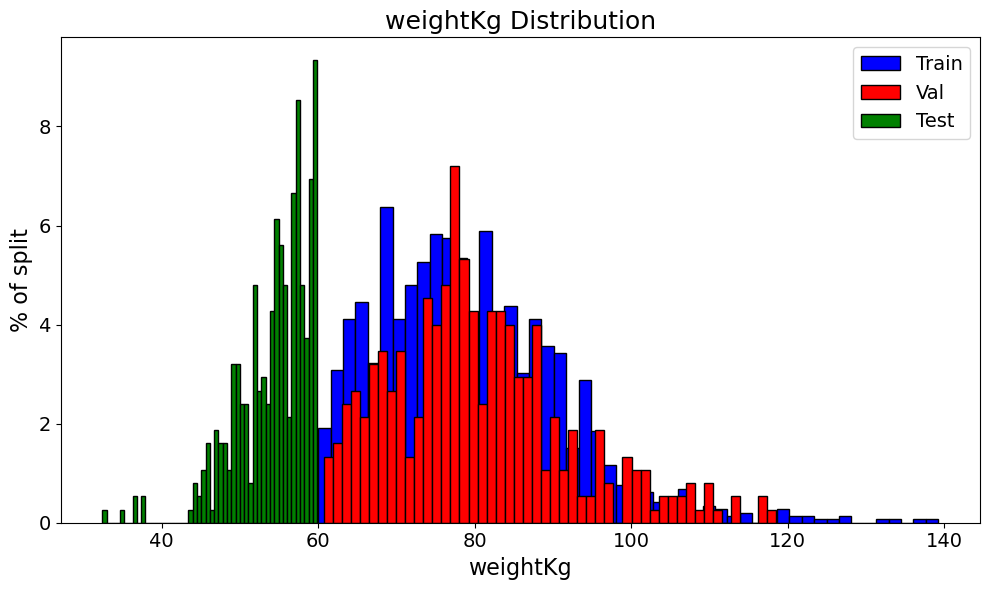

In [153]:
plot_histogram_comparison(train_df=w_train, val_df=w_val, test_df=w_test, feature="weightKg")

In [154]:
weight_dir = os.path.join(PROCESSED_PATH, "final_weight")
save_new_datasets(train=w_train, val=w_val, test=w_test, cat_cols=categorical_cols, con_cols=continuous_cols, save_directory=weight_dir, image_directory=PROCESSED_PATH)

Saved lengths to /data/local/kgutjahr/datasets/ADNI/dataset_files/final_weight/tabular_lengths.pt
Saved labels to /data/local/kgutjahr/datasets/ADNI/dataset_files/final_weight/labels_train.pt
Saved image paths to /data/local/kgutjahr/datasets/ADNI/dataset_files/final_weight/image_paths_train.pt
Saved ADNI Features to /data/local/kgutjahr/datasets/ADNI/dataset_files/final_weight/adni_features_train.csv
Saved labels to /data/local/kgutjahr/datasets/ADNI/dataset_files/final_weight/labels_val.pt
Saved image paths to /data/local/kgutjahr/datasets/ADNI/dataset_files/final_weight/image_paths_val.pt
Saved ADNI Features to /data/local/kgutjahr/datasets/ADNI/dataset_files/final_weight/adni_features_val.csv
Saved labels to /data/local/kgutjahr/datasets/ADNI/dataset_files/final_weight/labels_test.pt
Saved image paths to /data/local/kgutjahr/datasets/ADNI/dataset_files/final_weight/image_paths_test.pt
Saved ADNI Features to /data/local/kgutjahr/datasets/ADNI/dataset_files/final_weight/adni_features

## Shifts: Age

In [155]:
display(relevant_df_c["subjectAge"].quantile(0.15))
display(relevant_df_c["subjectAge"].quantile(0.85))

70.5753

83.72325999999998

In [156]:
age_train, age_val, age_test = create_shifted_splits(df=relevant_df_c, split=[{"subjectAge": (">=", 68)}, {"subjectAge": ("<=", 87)}], split_cond="and", ratio=[1850, 390, 380], con_columns=continuous_cols, cat_columns=categorical_cols, mode=1)

2208
410
Shape of train df:	(1725, 19)
Shape of val df:	(398, 19)
Shape of test df:	(380, 19)
Total Size: 2503
Ratio -> Train: 0.69 | Val: 0.16 | Test: 0.15


In [157]:
age_train, age_val, age_test = cut_datasets(train_df=age_train, val_df=age_val, test_df=age_test, sizes=[1460, 375, 375])

In [158]:
display([i for i in age_train["subjectIdentifier"].unique() if i in age_val["subjectIdentifier"].unique()])
display([i for i in age_train["subjectIdentifier"].unique() if i in age_test["subjectIdentifier"].unique()])
display([i for i in age_test["subjectIdentifier"].unique() if i in age_val["subjectIdentifier"].unique()])

[]

[]

[]

In [159]:
display(get_counts(df=age_train, feature="researchGroup"))
display(get_counts(df=age_val, feature="researchGroup"))
display(get_counts(df=age_test, feature="researchGroup"))

,Count,Percentage
MCI,721,49.384
CN,512,35.068
AD,227,15.548


,Count,Percentage
MCI,180,48.0
CN,138,36.8
AD,57,15.2


,Count,Percentage
MCI,248,66.133
AD,79,21.067
CN,48,12.8


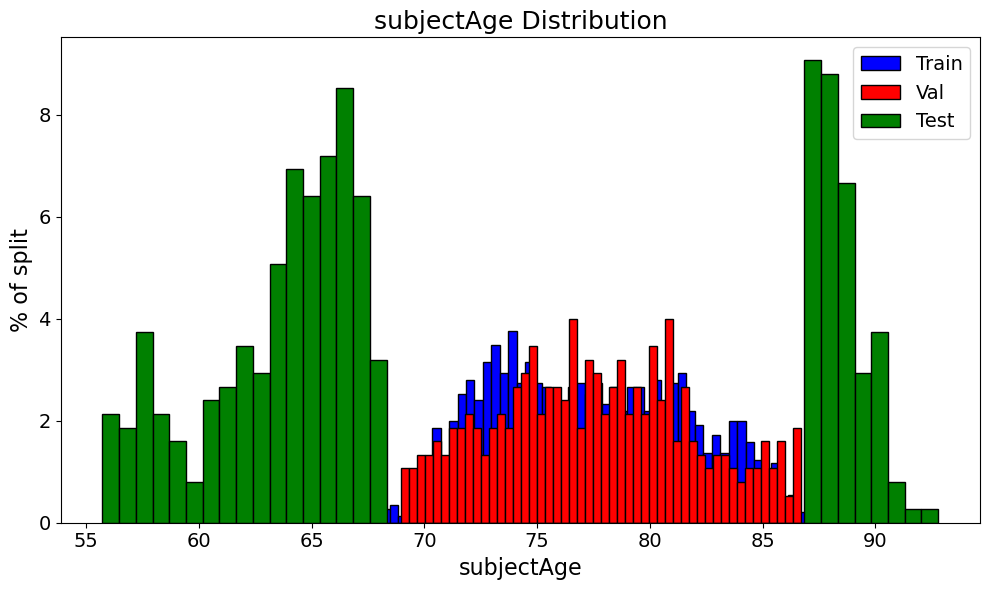

In [160]:
plot_histogram_comparison(train_df=age_train, val_df=age_val, test_df=age_test, feature="subjectAge")

In [161]:
age_dir = os.path.join(PROCESSED_PATH, "final_age")
save_new_datasets(train=age_train, val=age_val, test=age_test, cat_cols=categorical_cols, con_cols=continuous_cols, save_directory=age_dir, image_directory=PROCESSED_PATH)

Saved lengths to /data/local/kgutjahr/datasets/ADNI/dataset_files/final_age/tabular_lengths.pt
Saved labels to /data/local/kgutjahr/datasets/ADNI/dataset_files/final_age/labels_train.pt
Saved image paths to /data/local/kgutjahr/datasets/ADNI/dataset_files/final_age/image_paths_train.pt
Saved ADNI Features to /data/local/kgutjahr/datasets/ADNI/dataset_files/final_age/adni_features_train.csv
Saved labels to /data/local/kgutjahr/datasets/ADNI/dataset_files/final_age/labels_val.pt
Saved image paths to /data/local/kgutjahr/datasets/ADNI/dataset_files/final_age/image_paths_val.pt
Saved ADNI Features to /data/local/kgutjahr/datasets/ADNI/dataset_files/final_age/adni_features_val.csv
Saved labels to /data/local/kgutjahr/datasets/ADNI/dataset_files/final_age/labels_test.pt
Saved image paths to /data/local/kgutjahr/datasets/ADNI/dataset_files/final_age/image_paths_test.pt
Saved ADNI Features to /data/local/kgutjahr/datasets/ADNI/dataset_files/final_age/adni_features_test.csv


## Split: TE

In [162]:
split_col = "TE"
display(relevant_df_c[split_col].max())
display(relevant_df_c[split_col].min())
display(relevant_df_c[split_col].quantile(0.15))
display(relevant_df_c[split_col].quantile(0.85))

4.436

2.84

3.2544

3.9992

In [163]:
te_train, te_val, te_test = create_shifted_splits(df=relevant_df_c, split=[{"TE": (">=", 3.2544)}], split_cond="and", ratio=[1850, 390, 380], con_columns=continuous_cols+["TE"], cat_columns=categorical_cols, mode=1)

2240
378
Shape of train df:	(1461, 19)
Shape of val df:	(385, 19)
Shape of test df:	(378, 19)
Total Size: 2224
Ratio -> Train: 0.66 | Val: 0.17 | Test: 0.17


In [164]:
te_train, te_val, te_test = cut_datasets(train_df=te_train, val_df=te_val, test_df=te_test, sizes=[1460, 375, 375])

In [165]:
display([i for i in te_train["subjectIdentifier"].unique() if i in te_val["subjectIdentifier"].unique()])
display([i for i in te_train["subjectIdentifier"].unique() if i in te_test["subjectIdentifier"].unique()])
display([i for i in te_test["subjectIdentifier"].unique() if i in te_val["subjectIdentifier"].unique()])

[]

[]

[]

In [166]:
display(get_counts(df=te_train, feature="researchGroup"))
display(get_counts(df=te_val, feature="researchGroup"))
display(get_counts(df=te_test, feature="researchGroup"))

,Count,Percentage
MCI,793,54.315
CN,430,29.452
AD,237,16.233


,Count,Percentage
MCI,196,52.267
CN,112,29.867
AD,67,17.867


,Count,Percentage
MCI,190,50.667
CN,125,33.333
AD,60,16.0


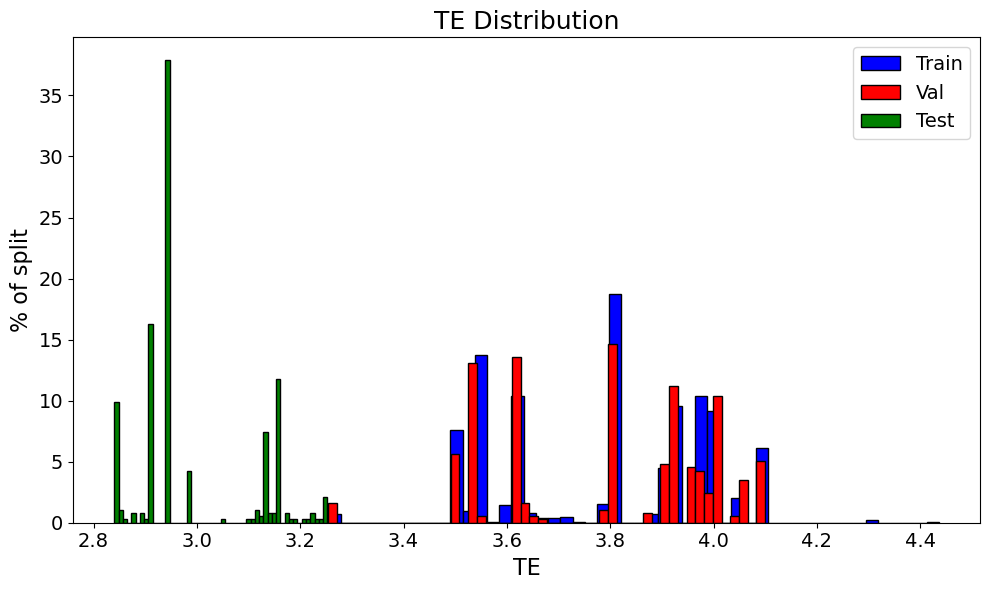

In [167]:
plot_histogram_comparison(train_df=te_train, val_df=te_val, test_df=te_test, feature=split_col)

In [168]:
te_dir = os.path.join(PROCESSED_PATH, "final_TE")
save_new_datasets(train=te_train, val=te_val, test=te_test, cat_cols=categorical_cols, con_cols=continuous_cols, save_directory=te_dir, image_directory=PROCESSED_PATH)

Saved lengths to /data/local/kgutjahr/datasets/ADNI/dataset_files/final_TE/tabular_lengths.pt
Saved labels to /data/local/kgutjahr/datasets/ADNI/dataset_files/final_TE/labels_train.pt
Saved image paths to /data/local/kgutjahr/datasets/ADNI/dataset_files/final_TE/image_paths_train.pt
Saved ADNI Features to /data/local/kgutjahr/datasets/ADNI/dataset_files/final_TE/adni_features_train.csv
Saved labels to /data/local/kgutjahr/datasets/ADNI/dataset_files/final_TE/labels_val.pt
Saved image paths to /data/local/kgutjahr/datasets/ADNI/dataset_files/final_TE/image_paths_val.pt
Saved ADNI Features to /data/local/kgutjahr/datasets/ADNI/dataset_files/final_TE/adni_features_val.csv
Saved labels to /data/local/kgutjahr/datasets/ADNI/dataset_files/final_TE/labels_test.pt
Saved image paths to /data/local/kgutjahr/datasets/ADNI/dataset_files/final_TE/image_paths_test.pt
Saved ADNI Features to /data/local/kgutjahr/datasets/ADNI/dataset_files/final_TE/adni_features_test.csv


## Split: Field Strength

In [355]:
fe_train, fe_val, fe_test = create_shifted_splits(df=relevant_df_c, split=[{"Field Strength": ("!=", 3.0)}, {"Field Strength": ("!=", 2.89362)}], split_cond="and", ratio=[1850, 390, 380], con_columns=continuous_cols+["Field Strength"], cat_columns=categorical_cols, mode=1)

2217
401
Shape of train df:	(1478, 19)
Shape of val df:	(375, 19)
Shape of test df:	(377, 19)
Total Size: 2230
Ratio -> Train: 0.66 | Val: 0.17 | Test: 0.17


In [356]:
display([i for i in fe_train["subjectIdentifier"].unique() if i in fe_val["subjectIdentifier"].unique()])
display([i for i in fe_train["subjectIdentifier"].unique() if i in fe_test["subjectIdentifier"].unique()])
display([i for i in fe_test["subjectIdentifier"].unique() if i in  fe_val["subjectIdentifier"].unique()])

[]

[]

[]